In [27]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import random
from itertools import combinations, chain
import functools
from typing import Callable
import math
import galois
from tqdm import tqdm

In [3]:
# Preparing types for data

# a 1D array of bits with shape size of M
Share = npt.NDArray[np.bool_] 
# a 2D array of bits with shape size of N x M
S_Matrix = npt.NDArray[np.bool_]

In [4]:
def display(share: Share | S_Matrix, fmt: tuple[int, int] = (1, -1), Label: str = "", grid=False) -> None:
    """Display a single share as an image."""
    _, ax = plt.subplots()
    # check if the share can be reshaped to the specified format
    if share.size != np.prod(fmt) and fmt != (1, -1):
        raise ValueError(f"Cannot reshape share of size {share.size} to format {fmt}.")
    
    # quick way to reshape the share if it's 1D, otherwise keep it as is
    match share.ndim:
        case 1: 
            share_reshaped = share.reshape(fmt)  
        case 2: 
            share_reshaped = share
        case _: 
            raise ValueError(f"Unsupported share dimensions: {share.ndim})")
    assert share_reshaped.ndim == 2, "Share must be 2D after reshaping."

    h, w = share_reshaped.shape
    ax.imshow(
        share_reshaped,
        cmap="gray_r",
        vmin=0,
        vmax=1
    )

    # Explicit separators on top of the image to avoid backend/style grid quirks
    if grid:
        for x in range(w + 1):
            ax.axvline(x - 0.5, color="lightgray", linewidth=1)
        for y in range(h + 1):
            ax.axhline(y - 0.5, color="lightgray", linewidth=1)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_title(Label)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    plt.show()

In [29]:
def shuffle(matrix: S_Matrix)-> None:
    """Shuffle the column of a matrix in place."""
    np.random.shuffle(matrix.T) 


def random_sampling_shares(S_0: S_Matrix, S_1: S_Matrix, secret_pixel: bool|None=None) ->tuple[bool, list[Share]]:
    """
    Emulate a Random share creation based on the two matrix S_0 and S_1 sampled from C_0 and C_1.
    based on a secrete pixel 
    
    output 
    - list share: the generated share as a 1D array of bits (size M) 
    """
    N, _ = S_0.shape
    
    secret_pixel_value = secret_pixel if secret_pixel is not None else np.random.choice([False, True])
    C = S_1 if secret_pixel_value else S_0

    # implementation column permutation
    col_order = np.random.permutation(C.shape[1])
    C_permuted = np.zeros_like(C)

    for new_pos, old_pos in enumerate(col_order):
        C_permuted[:, new_pos] = C[:, old_pos]
        
    C = C_permuted

    shares = []
    for i in range(N):
        share = C[i]
        shares.append(share)
    return secret_pixel_value, shares
    

Test matrix of shares:
[ True False  True False  True  True  True False]


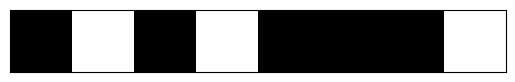

Test matrix 2 of shares:
[False False  True False  True  True False False]


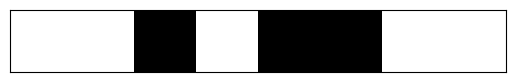

Result of share addition:
[ True False  True False  True  True  True False]


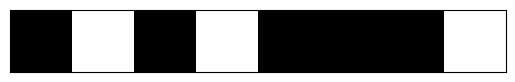

In [30]:
def share_add(a_share: Share, b_share: Share) -> Share:
    assert a_share.shape == b_share.shape, "Shares must have the same shape for addition."
    return np.logical_or(a_share, b_share)

def matrix_share_add(matrix_share: S_Matrix) -> Share:
    assert matrix_share.ndim == 2, "Input must be a 2D matrix of shares."
    return np.logical_or.reduce(matrix_share, axis=0)

SHARE_SIZE = (8,)
test_matrix = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
test_m2 = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
print("Test matrix of shares:")
print(test_matrix)
display(test_matrix)
print("Test matrix 2 of shares:")
print(test_m2)
display(test_m2)
result = share_add(test_matrix, test_m2)
print("Result of share addition:")
print(result)
display(result)

# First impl, 3 out of 3 shares
- size of shares: 4 bits
- number of shares: 3
- C=(3, 4)

Thus:

- $S_{0}$ is a column of 0s concatenated with negated identity matrix.
- $S_{1}$ is the negated version of S_0.

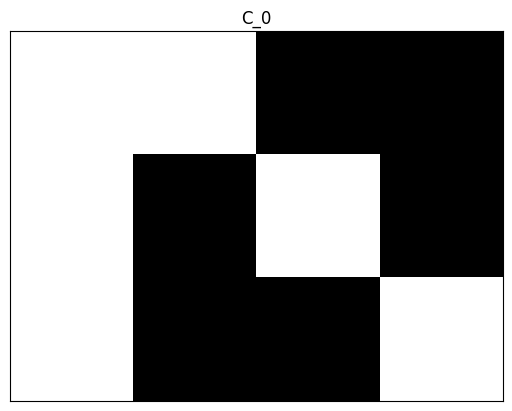

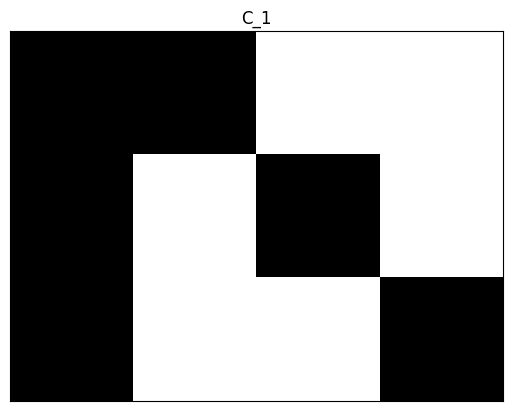

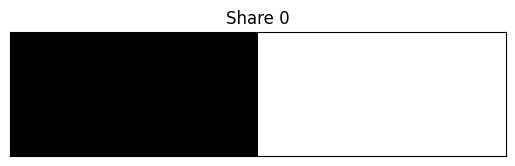

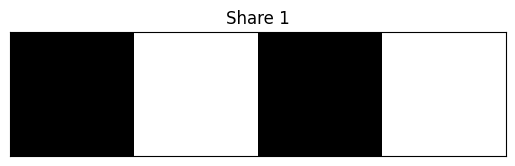

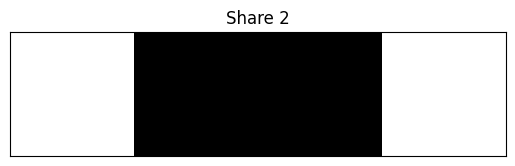

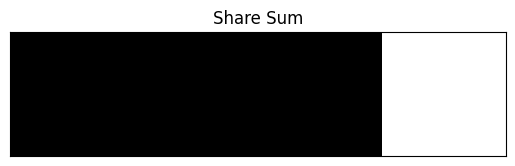

Average of share sum: 0.75
The secret should be False. (white, 0) 
Secret pixel value: False


In [31]:
def scheme_3_out_of_3():
    N = 3
    S_1 = np.hstack((np.ones((N, 1), dtype=bool), np.eye(N, dtype=bool)))
    return ~S_1 , S_1
    # currently we should have the following matrices for S0:
    #[[0, 1, 0, 0],
    # [0, 0, 1, 0],
    # [0, 0, 0, 1]]

S_0, S_1 = scheme_3_out_of_3()
threshold = 0.75
display(S_0, Label="C_0")
display(S_1, Label="C_1")

shuffle(S_0)
shuffle(S_1)

secret, shares = random_sampling_shares(S_0, S_1)
for i, share in enumerate(shares):
    display(share, Label=f"Share {i}")
share_sum = matrix_share_add(np.array(shares))
display(share_sum, Label="Share Sum")
avg = np.average(share_sum)

print(f"Average of share sum: {avg}")
if avg == threshold:
    print("The secret should be False. (white, 0) ")
elif avg == 1.0:
    print("The secret should be True. (black, 1) ")
print (f"Secret pixel value: {secret}")




# General K out of K scheme
- size of $k\times 2^{k-1}$
- m = $2^{k-1}$
- alpha = $1/2^k$
- r = $2^k !$

K out of K scheme 2:

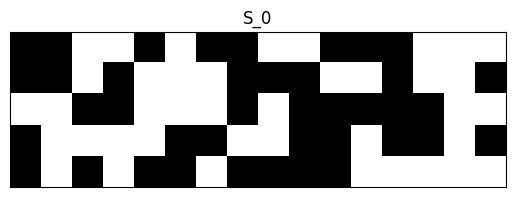

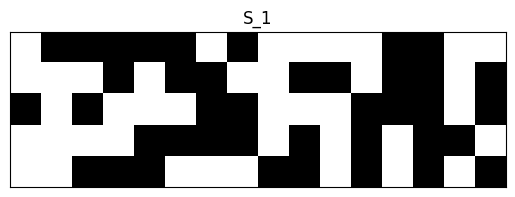

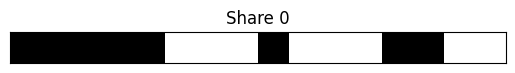

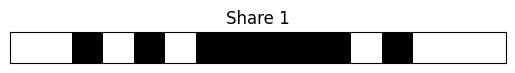

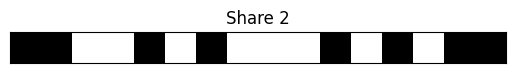

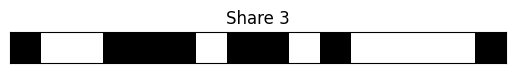

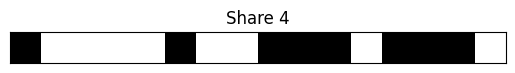

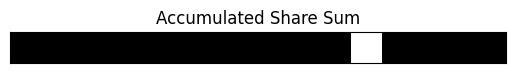

either 'True' if the summed share is all black (True) or 'False' if the summed share has a white pixel (False) 
the secret pixel value is False


In [35]:
K = 5
def powerset_even_odd(s: set) -> tuple[set, set]:
    """Generate the powerset of a given set."""
    all_subsets = set(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))) # see docs from itertools
    even_subsets = {subset for subset in all_subsets if len(subset) % 2 == 0}
    odd_subsets = all_subsets - even_subsets
    return even_subsets, odd_subsets

def generate_kok_matrices2(K: int) -> tuple[S_Matrix, S_Matrix]:
    M = 2**(K-1)
    
    S_0 = np.zeros((K,M), dtype=bool)
    S_1 = np.zeros((K,M), dtype=bool)
    
    W = set(range(K))
    PI, Sigma = powerset_even_odd(W)
    
    
    PI = list(PI)
    Sigma = list(Sigma)
    
    #sanity check 
    if len(PI) != M or len(Sigma) != M:
        raise ValueError(f"Expected 2^(K-1) subsets in both PI and Sigma, got {len(PI)} and {len(Sigma)}.")
    
    
    for i in W: # e_i or each element of W
        for j in range(M):
            if i in PI[j]:
                S_0[i, j] = True
            if i in Sigma[j]:
                S_1[i, j] = True
    return S_0, S_1
# proof check that S0 has one column containing all zeros and S1 has one column containing all ones
S_0, S_1 = generate_kok_matrices2(K)
display(S_0, Label="S_0")
display(S_1, Label="S_1")


secret, vals = random_sampling_shares(*generate_kok_matrices2(K))
for i, share in enumerate(vals):
    display(share, Label=f"Share {i}")

sum_share = functools.reduce(share_add, vals)
display(sum_share, Label="Accumulated Share Sum")
print(f"either 'True' if the summed share is all black (True) or 'False' if the summed share has a white pixel (False) ")
print("the secret pixel value is", secret)

# K out of N scheme:

## Hash family construction:
testing if the hash family construction is correct 
using a simple Monte Carlo approach.

In [36]:
def hash_family_construction(N: int, K: int, L: int|None = None) -> Callable:
    # primality check can skip if we use a idependent prime number generator, but from the paper it seems they just want to use K as the prime number for the field, so we can just check if K is prime.
    if K < 2:
        raise ValueError(f"k must be a prime number greater than 1, but got {K}.")
    i=1
    while (i:= i+1)**2 <= K:
        if K % i == 0:
            raise ValueError(f"k must be a prime number, but {K} is divisible by {i}.")
    
    
    # this is derive from formula of k**l >= n or traditionaly if P >= n 
    if L is None:
        L = math.ceil(math.log(N, K))
    elif K**L < N:
        raise ValueError(f"Invalid parameters: k^l must be >= n, but got k={K}, l={L}, and n={N}. either leave l as Default or increase l.")
    
    GF = galois.GF(K**L)
    coef = GF.Random(K)
    q = galois.Poly(coef, field=GF) # create a random polynomial of degree at most k-1 over the field GF(k^l)
    def h(x):
        return int(q(GF(x))) % K # equation -> h(x) = q(x) mod k, where q is a random polynomial of degree at most k-1 over the field GF(k^l) 
    h.poly = q # this was AI guided debugging.
    return h

    # alternative implementation without galois library, but was flagged as incorrect by AI 
    # reason -> simple modulo operation not being a field operation but more of a ring operation, so we will stick to the galois library implementation for correctness.
    # using numpy polyval(coeffs, x) to evaluate the polynomial at a given point x
    # GF_SIZE = K**L
    # coeffs = np.random.randint(0, high=GF_SIZE-1, size=(K,), dtype=int)
    # q_x = lambda x: np.polyval(coeffs, x) % GF_SIZE  # noqa: E731
    # h_x = lambda x: q_x(x) % K # noqa: E731
    # return h_x

100%|██████████| 100000/100000 [00:23<00:00, 4243.74it/s]


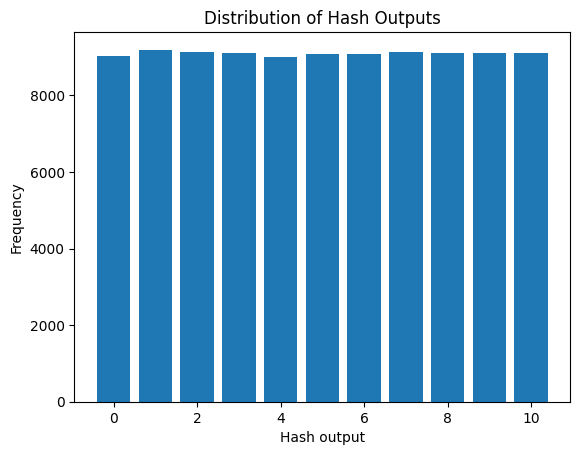

Estimating collision probability: 100%|██████████| 100000/100000 [00:46<00:00, 2133.87it/s]

Keys: x1=7, x2=8
Empirical collision prob : 0.0909
Theoretical bound (1/k)  : 0.0909


In [37]:
trial = 100_000
dic = dict()
k = 11
n = 25
for i in tqdm(range(trial)):
    h = hash_family_construction(N=n, K=k)
    test = h(random.randint(0, n ))
    dic[test] = dic.get(test, 0) + 1
plt.bar(dic.keys(), dic.values())
plt.xlabel("Hash output")
plt.ylabel("Frequency")
plt.title("Distribution of Hash Outputs")
plt.show()

x1, x2 = random.randint(0, n), random.randint(0, n)
collisions = sum(
    hash_family_construction(n, k)(x1) == hash_family_construction(n, k)(x2)
    for _ in tqdm(range(trial), desc="Estimating collision probability")
)
    
empirical = collisions / trial
theoretical_bound = 1 / k

print(f"Keys: x1={x1}, x2={x2}")
print(f"Empirical collision prob : {empirical:.4f}")
print(f"Theoretical bound (1/k)  : {theoretical_bound:.4f}")

## Core functions for the K out of N scheme 
( WIP )

In [ ]:
def T_matrices(k:int, r:int) -> tuple[list[S_Matrix], list[S_Matrix]]:
    #note that if the number of permutations of 2**(k-1) columns is less than r, we will not be able to generate r unique matrices, so we need to check that first.
    #note 2: as the paper didnt mention directly about the restrictions on r, we will asume that no there is no restriction with replacement on T_matrices, meaning we can have duplicate matrices in the sets as long as we have r matrices in total. this is because the paper only mentioned that T_matrices should be generated by shuffling the columns of the K out of K matrices, but didnt mention that they should be unique. so we will assume that we can have duplicate matrices in the sets as long as we have r matrices in total. (this is an attempt to have the function to work...)
    
    #sanity check
    # if math.factorial(2**(k-1)) < r:
    #     raise ValueError(f"Cannot generate {r} unique matrices from permutations of 2^(k-1) columns, as there are only {math.factorial(2**(k-1))} unique permutations.")
    
    C_0_set = []
    C_1_set = []
    
    kok_S_0, kok_S_1 = generate_kok_matrices2(k)
    
    mat_in = lambda mat, list_of_matrices: any(map(lambda x: np.array_equal(mat, x), list_of_matrices))
    
    while len(C_0_set) < r or len(C_1_set) < r:
        if len(C_0_set) < r:# and not mat_in(kok_S_0, C_0_set): # if the matrix is not already in the set, we can add it to the set until we have r unique matrices in each set.
            C_0_set.append(kok_S_0.copy()) # use copy to avoid reference issue when shuffling
            shuffle(kok_S_0)
        if len(C_1_set) < r:# and not mat_in(kok_S_1, C_1_set):
            C_1_set.append(kok_S_1.copy())
            shuffle(kok_S_1)
    assert len(C_0_set) == r, f"Expected {r} unique matrices in C_0_set, but got {len(C_0_set)}."
    assert len(C_1_set) == r, f"Expected {r} unique matrices in C_1_set, but got {len(C_1_set)}."
    return C_0_set, C_1_set


def upscale_kok_to_kon(kok_S: S_Matrix,h: Callable, n: int) -> S_Matrix:
    """
    Upscale a K out of K matrix to a K out of N matrix using the hash function h.
    from a matrix of size (k, 2^(k-1)) to a matrix of size (n, 2^(k-1)) by using the hash function h  
    """
    _, m = kok_S.shape
    kon_S = np.zeros((n, m), dtype=bool) # should be a n*2^(k-1) matrix
    for i in range(n):
        hi = h(i)
        kon_S[i] = kok_S[hi]
    return kon_S

def generate_kon_matrices(n:int ,k: int, r:int) -> tuple[S_Matrix, S_Matrix]:
    """Generate the S_0 and S_1 matrices for the K out of N scheme."""
    kok_C_0_set, kok_C_1_set = T_matrices(k, r)
    random.shuffle(kok_C_0_set)
    random.shuffle(kok_C_1_set)
    _, m = kok_C_0_set[0].shape
    
    l = r # as l not being specified in the paper, we will assume l = r but this may be the issue of the attenpt of implementing the function, as the paper is not clear about how to choose l.
    kon_S0 = np.zeros((n, m*l), dtype=bool)
    kon_S1 = np.zeros((n, m*l), dtype=bool)
    for l_idx in range(l):
        # the approach here is to generate a new hash function for each submatrix to ensure independence, then concatenate the upscaled matrices to form the final S_0 and S_1 matrices for the K out of N scheme such as we respect the V = U X H as mentioned in the paper.
        hash_func = hash_family_construction(N=n, K=k) # generate a new hash function for each submatrix to ensure independence
        sub_kon_S0 = upscale_kok_to_kon(kok_C_0_set[l_idx], hash_func, n)
        sub_kon_S1 = upscale_kok_to_kon(kok_C_1_set[l_idx], hash_func, n)
        kon_S0[:, l_idx*m:(l_idx+1)*m] = sub_kon_S0
        kon_S1[:, l_idx*m:(l_idx+1)*m] = sub_kon_S1
    return kon_S0, kon_S1

Generated initial K out of K matrices for k=3. Starting to generate 64 unique matrices for C_0 and C_1 by shuffling columns.


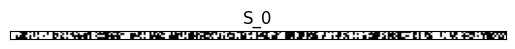

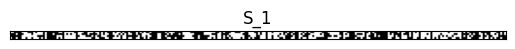

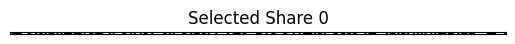

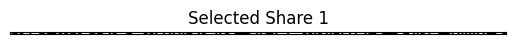

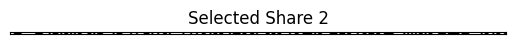

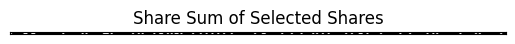

Alpha (difference between count of 1s and 0s in share sum): 146
Hamming weight of share sum: 201
Secret pixel value: True


In [12]:
N = 4
K = 3
R = N**K
S0, S1 = generate_kon_matrices(n=N, k=K, r=R)
shuffle(S0)
shuffle(S1)
display(S0, Label="S_0")
display(S1, Label="S_1")
secret , shares = random_sampling_shares(S0, S1)

# get k random shares and check if we can recover the secret
selected_shares = random.sample(shares, k=K)
for i, share in enumerate(selected_shares):
    display(share, Label=f"Selected Share {i}")
share_sum = functools.reduce(share_add, selected_shares)
display(share_sum, Label="Share Sum of Selected Shares")
hamming_weight = np.sum(share_sum) # we can also use the average of the share sum to determine the secret pixel value, as the average will be around 1 for black pixel and around 0 for white pixel, with a threshold of 0.5. but here we will stick to the hamming weight for simplicity.
alpha = hamming_weight -(len(share_sum)-hamming_weight) # this is the difference between the number of 1s and 0s in the share sum, which should be positive for black pixel and negative for white pixel.
print(f"Alpha (difference between count of 1s and 0s in share sum): {alpha}")
print(f"Hamming weight of share sum: {hamming_weight}")
print (f"Secret pixel value: {secret}")


The above code is the attempt of implementing the k out of n scheme. As this is does not give us a clear separation on the S_1 and S_0 as the result were not binary (or split between groups) thus the implementation needs to be revised due a possible error. 

# a real example

using a basic 3,3 scheme to show how the shares look like and how the reconstruction works. using a simple image that we converted to binary.

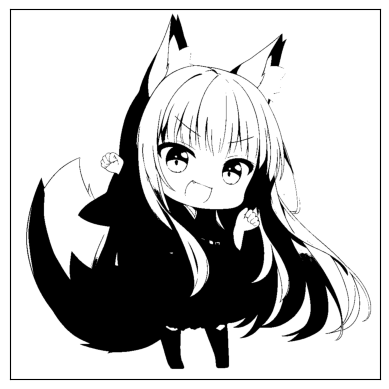

In [ ]:
from PIL import Image
def load_and_binarize_image(image_path: str, threshold: int = 128) -> S_Matrix:
    """Load an image, convert it to grayscale, and binarize it using a given threshold."""
    img = Image.open(image_path).convert("L") # convert to grayscale
    binary_img = img.point(lambda p: p < threshold, mode='1') # convert to binary image using the specified threshold
    return np.array(binary_img, dtype=bool)
binary_image = load_and_binarize_image("holo_chibi.png")
display(binary_image)


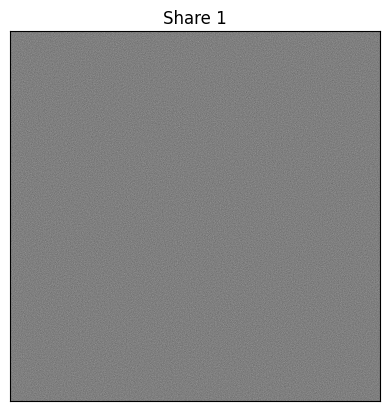

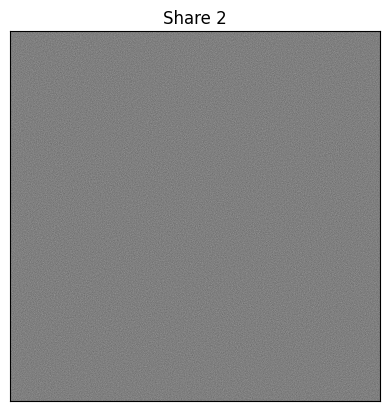

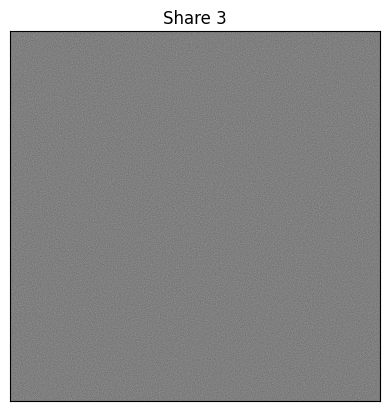

In [ ]:
def encrypt_33_shares(binary_image: S_Matrix):
    """
    Generate 3-out-of-3 visual cryptography shares.

    Each pixel expands into a 2x2 block.
    All three shares are required for reconstruction.
    """

    width, height = binary_image.shape

    # Each pixel becomes a 2x2 block due to subpixel expansion in 3-out-of-3 scheme it is a 2x2 block
    share_width = width * 2
    share_height = height * 2

    share1 = np.zeros((share_width, share_height), dtype=bool) # start with all white shares
    share2 = np.zeros((share_width, share_height), dtype=bool)
    share3 = np.zeros((share_width, share_height), dtype=bool)


    S_0, S_1 = scheme_3_out_of_3()

    for y in range(height):
        for x in range(width):

            pixel = binary_image[x, y]
            is_black = (pixel == 1)

            block_x = x * 2
            block_y = y * 2
            
            s = S_1 if is_black else S_0
            
            p1 = s[0]
            p2 = s[1]
            p3 = s[2]
            shuffle(s) # due to adjacent pixel correlation we may end in a ECB like pattern, so we shuffle the rows.
            
            coords = [
                (block_x, block_y),
                (block_x + 1, block_y),
                (block_x, block_y + 1),
                (block_x + 1, block_y + 1)
            ]

            for i, (cx, cy) in enumerate(coords):
                share1[cx, cy] = 1 if p1[i] else 0
                share2[cx, cy] = 1 if p2[i] else 0
                share3[cx, cy] = 1 if p3[i] else 0

    return share1, share2, share3

share1, share2, share3 = encrypt_33_shares(binary_image)
display(share1, Label="Share 1")
display(share2, Label="Share 2")
display(share3, Label="Share 3")



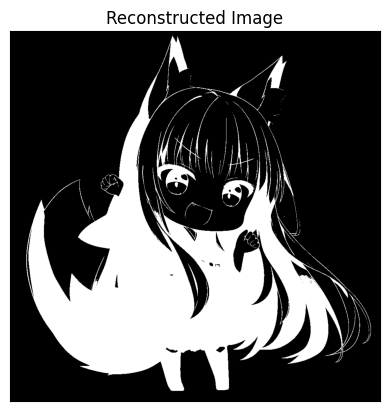

In [26]:
def decrypt_33_shares(share1: S_Matrix, share2: S_Matrix, share3: S_Matrix) -> S_Matrix:
    """Reconstruct the original image by overlaying the three shares."""
    if share1.shape != share2.shape or share2.shape != share3.shape:
        raise ValueError("All shares must have the same dimensions for decryption.")
    
    width, height = share1.shape
    original_width = width // 2
    original_height = height // 2
    
    
    reconstructed_image = np.zeros((original_width, original_height), dtype=bool)
    for y in range(original_height):
        for x in range(original_width):
            block_x = x * 2
            block_y = y * 2
            
            # Overlay the corresponding 2x2 blocks from all three shares
            block1 = np.ravel(share1[block_x:block_x+2, block_y:block_y+2])
            block2 = np.ravel(share2[block_x:block_x+2, block_y:block_y+2])
            block3 = np.ravel(share3[block_x:block_x+2, block_y:block_y+2])
            
            
            # .87 can be anything between ]0.75, 1[, due to how 3-out-of-3 scheme works cf the paper.
            if np.mean(functools.reduce(share_add, [block1, block2, block3])) > 0.87: 
                reconstructed_image[x, y] = 0 # black pixel
            else:
                reconstructed_image[x, y] = 1 # white pixel
            

    return reconstructed_image
reconstructed_image = decrypt_33_shares(share1, share2, share3)
display(reconstructed_image, Label="Reconstructed Image")
    